Для Python 3.10 следующий набор версий библиотек рабочий и не падает с ошибками при выполнении данного ноутбука:

<ul>
    <li>pandas==2.0.3</li>
    <li>numpy==1.24.4</li>
    <li>statsmodels==0.14.4</li>
    <li>matplotlib==3.10.0</li>
    <li>scipy==1.10.1</li>
    <li>statsmodels==0.14.4</li>
    <li>sklearn==1.6.1</li>
    <li>arch==7.2.0</li>
</ul>


# Лекция 3
## Модели ARIMA и GARCH

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.tsa.api as smt

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox

In [2]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [3]:
def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC', result_object=False)
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

In [4]:
def tsplot(y, lags=None, figsize=(14, 8), style='bmh'):
    test_stationarity(y)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (7, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0), rowspan=2)
        pacf_ax = plt.subplot2grid(layout, (4, 0), rowspan=2)
        qq_ax = plt.subplot2grid(layout, (6, 0))

        y.plot(ax=ts_ax, color='blue', label='Or')
        ts_ax.set_title('Original')

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)
        sm.qqplot(y, line='s', ax=qq_ax)

        plt.tight_layout()
    return

## 1. Monthly Sales of Company X

Results of Dickey-Fuller Test:
Test Statistic                  0.654715
p-value                         0.988889
#Lags Used                     12.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64


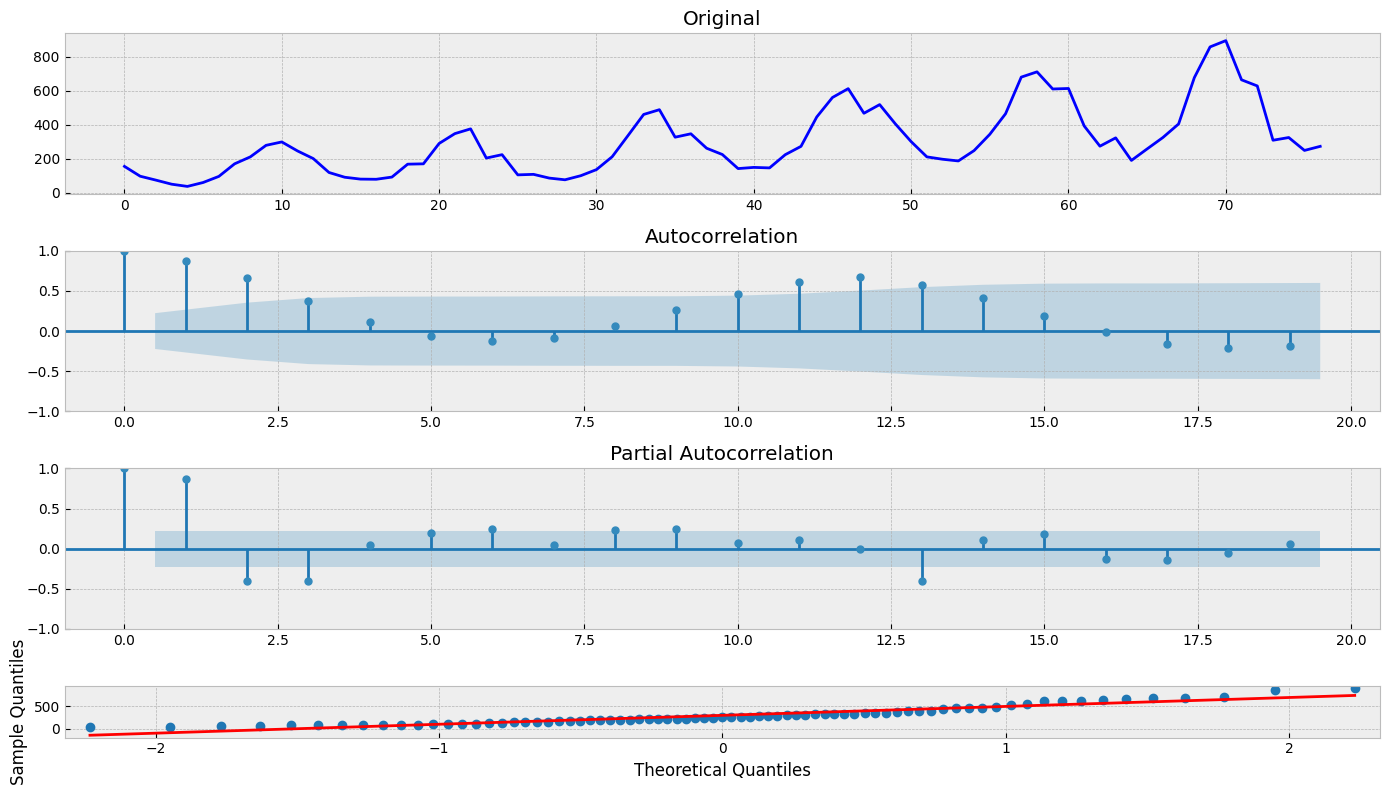

In [5]:
series = pd.read_csv("monthly-sales-of-company-x-jan-6.csv")['Count']
tsplot(series)

Заметна увеличивающаяся дисперсия, что выражается в амплитуде колебаний. Для нормализации дисперсии прприменим boxcox:

Results of Dickey-Fuller Test:
Test Statistic                 -0.631279
p-value                         0.863757
#Lags Used                     12.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64


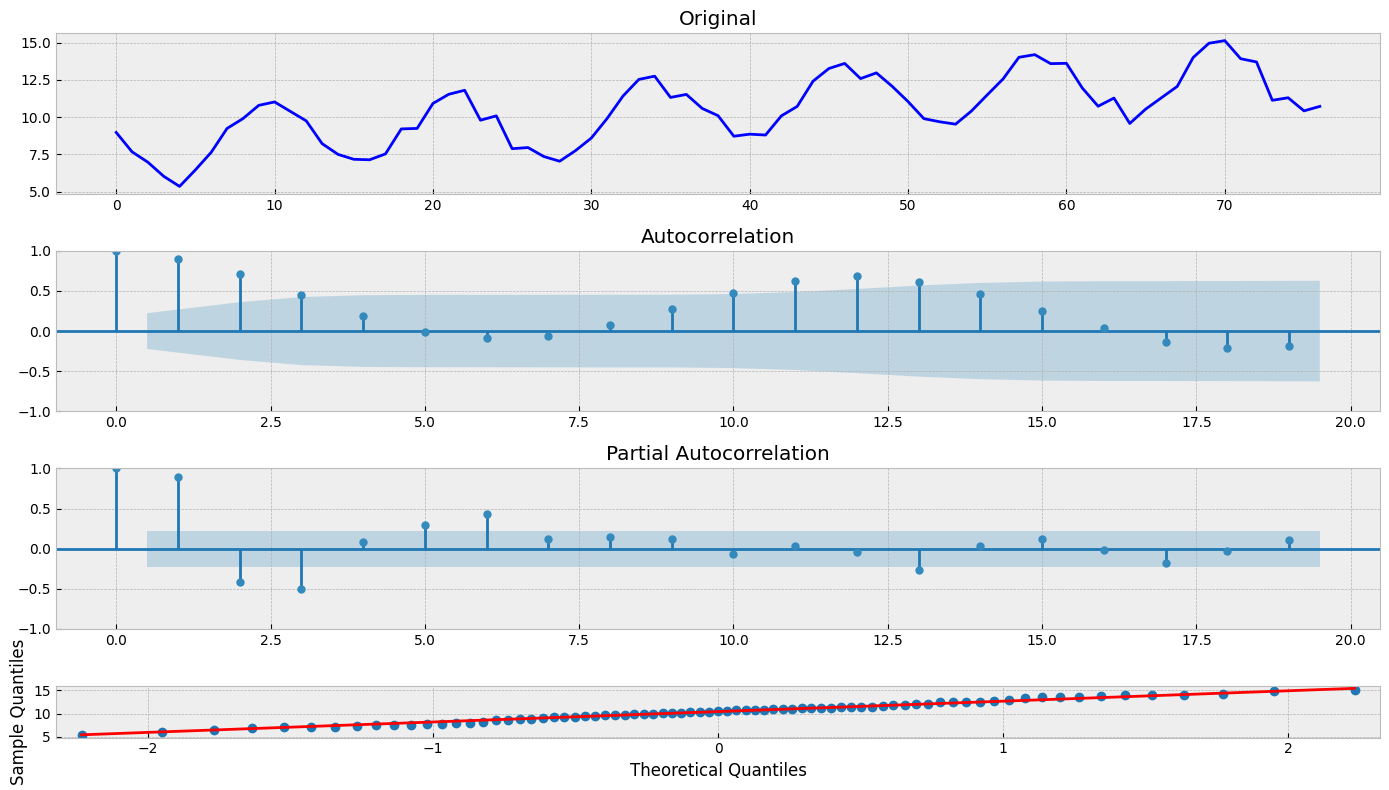

In [6]:
series = pd.read_csv("monthly-sales-of-company-x-jan-6.csv")['Count']
series = pd.Series(boxcox(series)[0])
tsplot(series)

In [7]:
# Загружаем модуль ARIMA
from statsmodels.tsa.arima.model import ARIMA

Для автоматического подбора параметров ARIMA будем использовать pmdarima

In [8]:
!pip install pmdarima
import pmdarima as pm

In [9]:
# Автоматический подбор параметров
auto_model = pm.auto_arima(
    y=series,
    start_p=1, start_q=1,
    max_p=5, max_q=5,
    d=None,           # d определится автоматически тестами на стационарность
    seasonal=False,   # если ряд сезонный, поставьте True
    trace=True        # показывает процесс перебора в консоли
)

print(auto_model.summary())


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=216.302, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=223.656, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=216.701, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=220.698, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=221.694, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=208.769, Time=0.42 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=209.867, Time=0.04 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.96 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=194.966, Time=1.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=197.210, Time=0.54 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=138.216, Time=3.25 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=142.773, Time=4.54 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=136.240, Time=1.67 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=136.147, Time=1.43 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=197.761, 

Обучаем модель с найденными оптимальными параметрами:

In [10]:
mdl = ARIMA(series, order=auto_model.order, trend='t').fit()

Строим график остатков предсказания:

Results of Dickey-Fuller Test:
Test Statistic                -21.666046
p-value                         0.000000
#Lags Used                      0.000000
Number of Observations Used    76.000000
Critical Value (1%)            -3.519481
Critical Value (5%)            -2.900395
Critical Value (10%)           -2.587498
dtype: float64


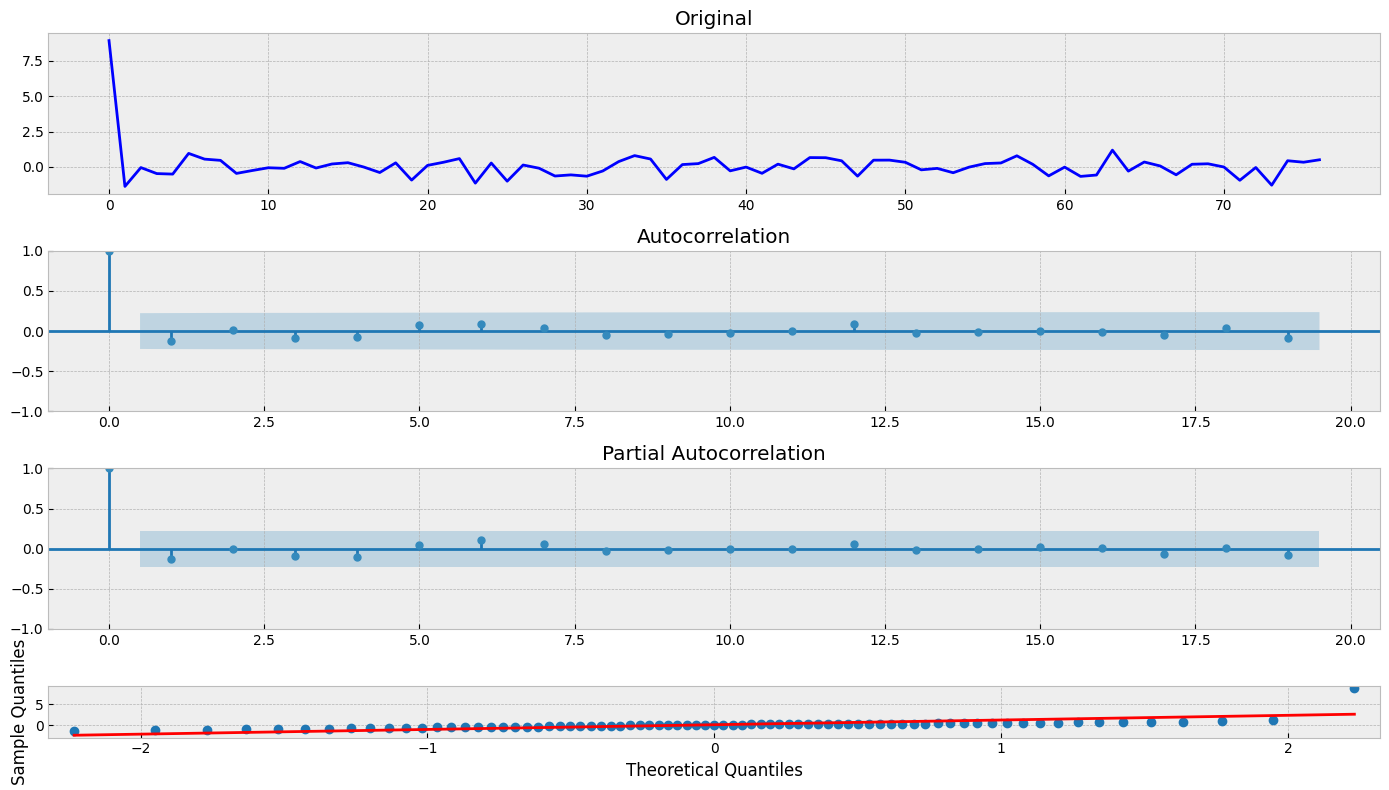

In [11]:
tsplot(mdl.resid)

График сопоставления реальных данных и предсказаний:

In [12]:
from statsmodels.graphics.tsaplots import plot_predict

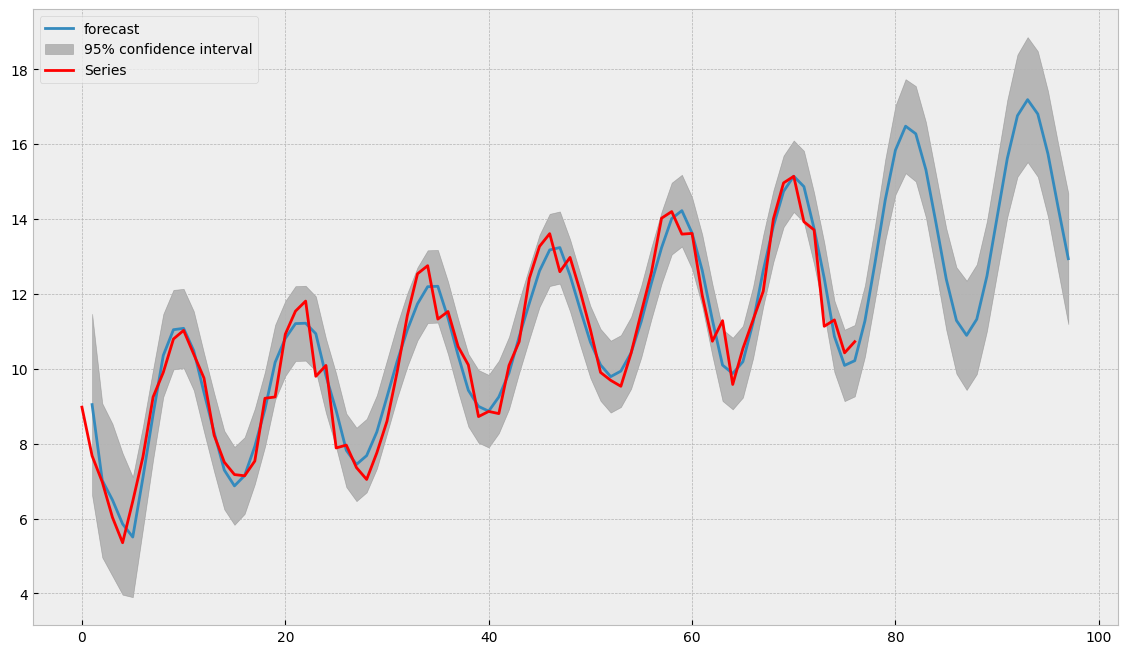

In [13]:
with plt.style.context('bmh'):
    plt.figure(figsize=(14,8))
    ax = plt.axes()
    plot_predict(mdl, 1, len(series)+20, ax=ax)
    plt.plot(series, color='red', label='Series')
    plt.legend()
    plt.show()